In [2]:
import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Step 1: Load a large CSV dataset using Dask
# For simulation purposes, we will generate a large CSV file with dummy data
# You can replace this with a real CSV file path (e.g., 'path/to/your/large_dataset.csv')

# Let's generate a dummy dataset of reviews


In [6]:
# Let's generate a dummy dataset of reviews
data = {
    'product': ['ProductA', 'ProductB', 'ProductC', 'ProductA', 'ProductB'] * 100000,
    'rating': [5, 4, 3, 2, 5] * 100000,
    'review': ['Great', 'Good', 'Okay', 'Bad', 'Excellent'] * 100000
}


In [8]:
# Convert to pandas DataFrame and save as a CSV
df = pd.DataFrame(data)
df.to_csv('large_reviews.csv', index=False)

In [10]:
# Step 2: Load dataset using Dask
df_dask = dd.read_csv('large_reviews.csv')


In [12]:
# Step 3: Perform analysis
# 1. Calculate the average rating per product
avg_rating = df_dask.groupby('product')['rating'].mean().compute()

In [14]:
# 2. Calculate the number of reviews per product
review_count = df_dask.groupby('product').size().compute()

In [16]:
# Step 4: Display Results
print("Average Rating per Product:")
print(avg_rating)
print("\nReview Count per Product:")
print(review_count)


Average Rating per Product:
product
ProductA    3.5
ProductB    4.5
ProductC    3.0
Name: rating, dtype: float64

Review Count per Product:
product
ProductA    200000
ProductB    200000
ProductC    100000
dtype: int64


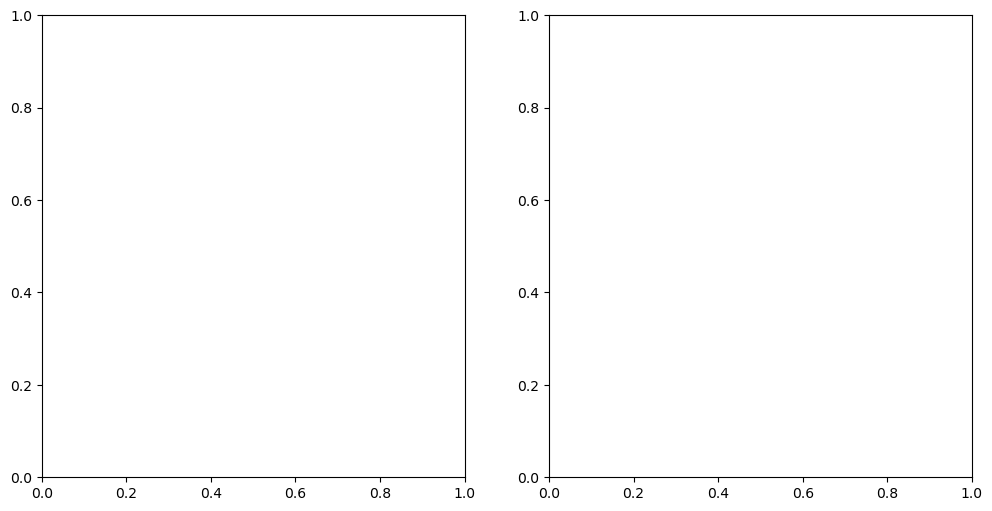

In [18]:
# Step 5: Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

In [20]:
# Plot average rating
avg_rating.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Average Rating per Product')

Text(0.5, 1.0, 'Average Rating per Product')

In [22]:
# Plot review count
review_count.plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Review Count per Product')

Text(0.5, 1.0, 'Review Count per Product')

In [24]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>